In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [11]:
df = pd.read_csv("data/cars.csv")
make = "nissan"
selected_models = ['altima', 'rogue', 'sentra', 'frontier', 'murano', '370z']
make_df = df[(df["make"] == make) & (df["model"].isin(selected_models))].copy()
make_df["model"] = pd.Categorical(make_df["model"], categories=selected_models, ordered=True)
make_df = make_df.sort_values("model")


### Nissan price outlier cleanup

The selected nissan model subset still has upper-tail price outliers. This step computes the 99th percentile price within that filtered subset and creates `df_clean` by keeping only rows at or below that cutoff. The scatterplots below use `df_clean` so the main price relationships are easier to inspect.


In [12]:
price_upper = make_df["price"].quantile(0.99)

df_clean = make_df[make_df["price"] <= price_upper].copy()

print(f"99th percentile price cutoff: ${price_upper:,.0f}")
print(f"Rows before cleanup: {len(make_df):,}")
print(f"Rows after cleanup: {len(df_clean):,}")
print(f"Rows removed: {len(make_df) - len(df_clean):,}")


99th percentile price cutoff: $39,990
Rows before cleanup: 8,762
Rows after cleanup: 8,756
Rows removed: 6


### Cleaned Nissan price vs odometer

This scatterplot shows price versus odometer reading for the selected representative nissan models after removing the top 1% of prices from the filtered subset. Using `df_clean` reduces the influence of extreme listings while preserving the model comparison.


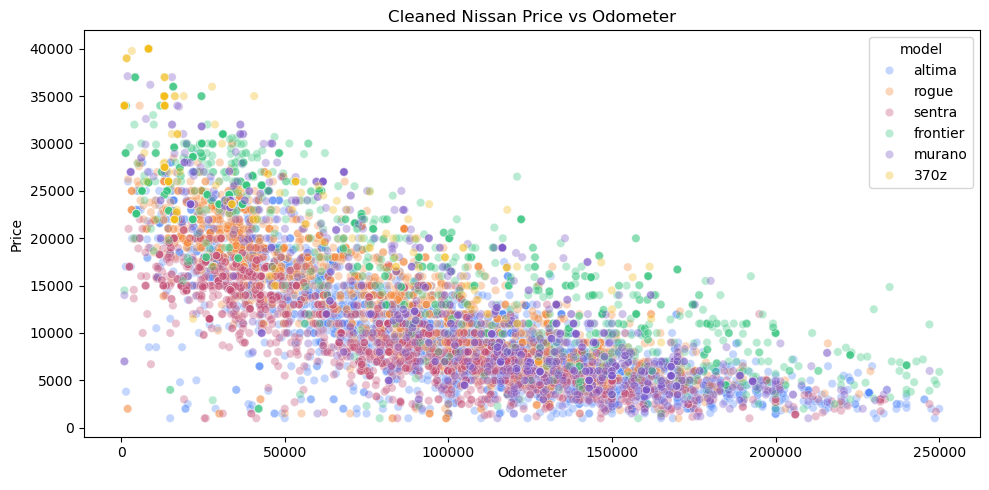

In [13]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x="odometer", y="price", hue="model", alpha=0.35)
plt.title("Cleaned Nissan Price vs Odometer")
plt.xlabel("Odometer")
plt.ylabel("Price")
plt.tight_layout()


### Cleaned Nissan price vs age

This scatterplot shows price versus age for the selected representative nissan models after removing the top 1% of prices from the filtered subset. The cleaned view makes depreciation patterns easier to inspect across the chosen models.


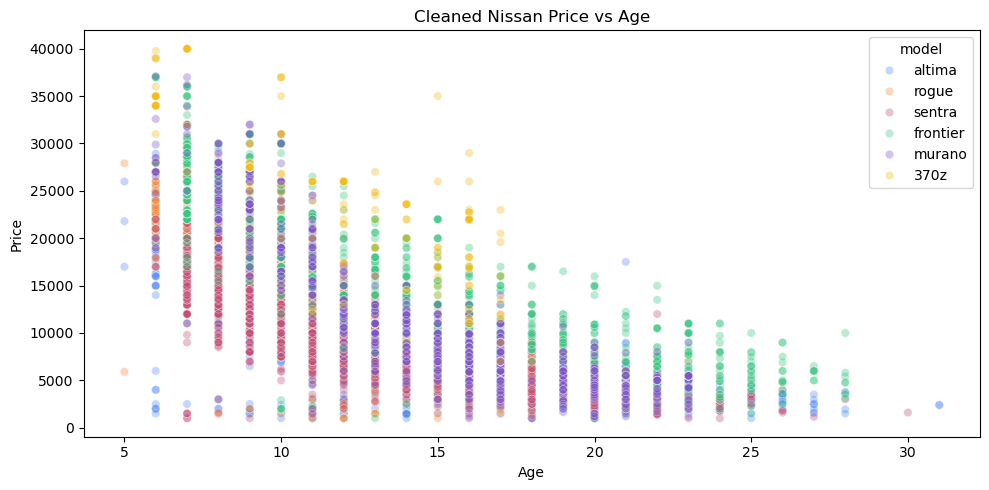

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x="age", y="price", hue="model", alpha=0.35)
plt.title("Cleaned Nissan Price vs Age")
plt.xlabel("Age")
plt.ylabel("Price")
plt.tight_layout()


### Median Nissan price by model

This bar chart compares median cleaned price across all nissan models in the dataset, not just the representative subset used in the scatterplots. It first removes the top 1% of prices within the full nissan subset, then summarizes the remaining listings by model.


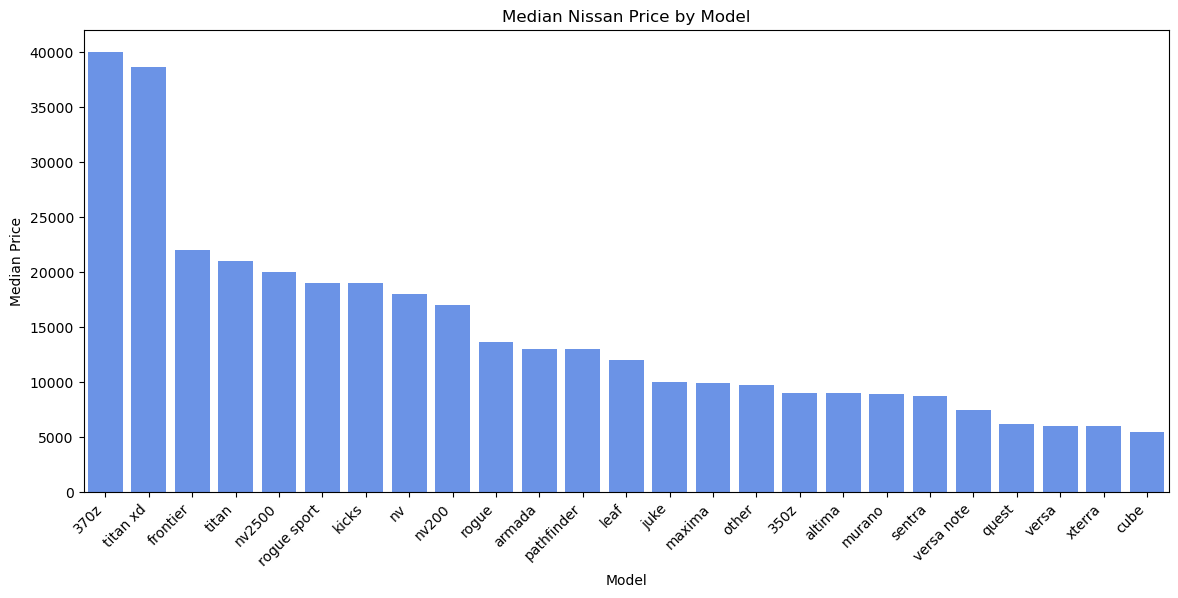

In [15]:
all_make_df = df[df["make"] == "nissan"].copy()
all_make_price_upper = all_make_df["price"].quantile(0.99)
all_make_df_clean = all_make_df[all_make_df["price"] <= all_make_price_upper].copy()

model_price = (
    all_make_df_clean.groupby("model", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(14, 6))
sns.barplot(data=model_price, x="model", y="price")
plt.title("Median Nissan Price by Model")
plt.xlabel("Model")
plt.ylabel("Median Price")
plt.xticks(rotation=45, ha="right")
plt.show()


### Median Nissan price by condition

This bar chart compares median cleaned price across condition categories for all nissan listings. It uses the full nissan subset after the top 1% price cleanup, so the category comparison is less affected by extreme high-price listings.


In [ ]:
condition_price = (
    all_make_df_clean.dropna(subset=["condition"])
    .groupby("condition", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=condition_price, x="condition", y="price")
plt.title("Median Nissan Price by Condition")
plt.xlabel("Condition")
plt.ylabel("Median Price")
plt.xticks(rotation=45, ha="right")
plt.show()


### Median Nissan price by cylinders

This bar chart compares median cleaned price across engine cylinder categories for all nissan listings. It uses the full nissan subset after the top 1% price cleanup, so the category comparison is less affected by extreme high-price listings.


In [ ]:
cylinders_price = (
    all_make_df_clean.dropna(subset=["cylinders"])
    .groupby("cylinders", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=cylinders_price, x="cylinders", y="price")
plt.title("Median Nissan Price by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Median Price")
plt.xticks(rotation=45, ha="right")
plt.show()


### Median Nissan price by fuel

This bar chart compares median cleaned price across fuel types for all nissan listings. It uses the full nissan subset after the top 1% price cleanup, so the category comparison is less affected by extreme high-price listings.


In [ ]:
fuel_price = (
    all_make_df_clean.dropna(subset=["fuel"])
    .groupby("fuel", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=fuel_price, x="fuel", y="price")
plt.title("Median Nissan Price by Fuel")
plt.xlabel("Fuel")
plt.ylabel("Median Price")
plt.xticks(rotation=45, ha="right")
plt.show()


### Median Nissan price by transmission

This bar chart compares median cleaned price across transmission types for all nissan listings. It uses the full nissan subset after the top 1% price cleanup, so the category comparison is less affected by extreme high-price listings.


In [ ]:
transmission_price = (
    all_make_df_clean.dropna(subset=["transmission"])
    .groupby("transmission", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=transmission_price, x="transmission", y="price")
plt.title("Median Nissan Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Median Price")
plt.xticks(rotation=45, ha="right")
plt.show()


### Median Nissan price by drive

This bar chart compares median cleaned price across drive types for all nissan listings. It uses the full nissan subset after the top 1% price cleanup, so the category comparison is less affected by extreme high-price listings.


In [ ]:
drive_price = (
    all_make_df_clean.dropna(subset=["drive"])
    .groupby("drive", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=drive_price, x="drive", y="price")
plt.title("Median Nissan Price by Drive")
plt.xlabel("Drive")
plt.ylabel("Median Price")
plt.xticks(rotation=45, ha="right")
plt.show()


### Median Nissan price by type

This bar chart compares median cleaned price across vehicle body types for all nissan listings. It uses the full nissan subset after the top 1% price cleanup, so the category comparison is less affected by extreme high-price listings.


In [ ]:
type_price = (
    all_make_df_clean.dropna(subset=["type"])
    .groupby("type", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=type_price, x="type", y="price")
plt.title("Median Nissan Price by Type")
plt.xlabel("Type")
plt.ylabel("Median Price")
plt.xticks(rotation=45, ha="right")
plt.show()
